# WET-004: Donut Deblending Test

Owner: **Bryce Kalmbach** <br>
Last Verified to Run: **2025-03-27** <br>
Software Version:
  - `ts_wep`: **14.1.1** 
  - `lsst_distrib`: **w_2025_11**

In [150]:
# Times Square Parameters
collection_name = 'u/brycek/aosRefitWcs_danish_singleBlends_80pxMinSep'
detector = 0
min_seq_num = 90
max_seq_num = 107
day_obs = 20241115

In [151]:
import numpy as np
from copy import copy
from astropy.visualization import ZScaleInterval
from matplotlib import pyplot as plt
from lsst.daf.butler import Butler

from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.palettes import Viridis256
from bokeh.models import LinearColorMapper, LabelSet, Label, ColorBar
output_notebook()
%matplotlib inline

Loading BokehJS ...

In [152]:
butler = Butler('/repo/main')

In [153]:
camera = butler.get('camera', {'instrument': "LSSTComCam"}, collections=collection_name)

In [154]:
def bin2d(a,K):
    m_bins = a.shape[0]//K
    n_bins = a.shape[1]//K
    return a.reshape(m_bins, K, n_bins, K).sum(3).sum(1)

## Identify Blended Donuts

In [162]:
refs_with_visit_tables = butler.query_datasets('aggregateAOSVisitTableRaw', 
                                             collections=collection_name,
                                             where=f"exposure.day_obs = {day_obs} and exposure.seq_num >= {min_seq_num} and exposure.seq_num <= {max_seq_num} and instrument = 'LSSTComCam'")

In [178]:
ref_on = 4
dt = butler.get(refs_with_visit_tables[ref_on])
dataId = refs_with_visit_tables[ref_on].to_simple().dataId.dataId

In [179]:
blended_idx = list()
blend_x = list()
blend_y = list()
for idx, loc in enumerate(dt.meta['blendInfo']['blend_centroid_x']):
    if len(loc) > 0:
        blended_idx.append(idx)
        blend_x.append(dt.meta['blendInfo']['blend_centroid_x'][idx][0])
        blend_y.append(dt.meta['blendInfo']['blend_centroid_y'][idx][0])
blend_x = np.array(blend_x)
blend_y = np.array(blend_y)

In [180]:
dt.meta

{'visit': 2024111500103,
 'parallacticAngle': 2.26576090616642,
 'rotAngle': 2.91194624965483,
 'rotTelPos': -2.2169816702833067,
 'ra': 6.07326901578982,
 'dec': -0.191324572788331,
 'az': 5.22671446395795,
 'alt': 0.990203116208281,
 'mjd': 60630.09068865455,
 'nollIndices': array([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 20, 21, 22, 27, 28]),
 'blendInfo': {'blend_centroid_x': [[],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   []],
  'blend_centroid_y': [[],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   [],
   

In [181]:
dt_blended = dt[blended_idx]
dt_blended['blend_centroid_x'] = blend_x
dt_blended['blend_centroid_y'] = blend_y
separation = np.sqrt((dt_blended['blend_centroid_x'] - dt_blended['centroid_x'])**2 + (dt_blended['blend_centroid_y'] - dt_blended['centroid_y'])**2)
dt_blended['separation'] = separation

In [159]:
dt_blended

coord_ra,coord_dec,centroid_x,centroid_y,monster_SynthLSST_u_flux,monster_SynthLSST_g_flux,monster_SynthLSST_r_flux,monster_SynthLSST_i_flux,monster_SynthLSST_z_flux,monster_SynthLSST_y_flux,detector,blend_centroid_x,blend_centroid_y,separation
rad,rad,,,nJy,nJy,nJy,nJy,nJy,nJy,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str7,float64,float64,float64
6.076460071912474,-0.1849872828580281,2380.559093160402,962.0784671614056,67091.12164511718,218580.44607861698,345352.69941754756,391040.344689985,401245.7822850736,nan,R22_S02,2513.22293744564,1004.2855928494637,139.2161522215919
6.075255247564552,-0.1851069733073142,1165.4407270071024,804.4287676653985,nan,62559.40534352307,167667.3585103689,234494.86047702865,284711.3191455972,nan,R22_S02,1117.1414473358968,947.0364334550868,150.5648257686395
6.077161542324807,-0.18572146212319546,2900.0789768490504,1859.6304278554308,nan,23307.116924215366,84678.20053389094,247230.94298079432,416784.1589517173,nan,R22_S02,3008.338858634709,1823.5171722710202,114.12435863193173


In [160]:
quality_table = butler.get('donutQualityTable', dataId=dataId, collections=collection_name)

DatasetNotFoundError: Dataset donutQualityTable with data ID {instrument: 'LSSTComCam', detector: 2, visit: 2024111500105, band: 'r', day_obs: 20241115, physical_filter: 'r_03'} could not be found in collections u/brycek/aosRefitWcs_danish_singleBlends_80pxMinSep.

In [161]:
quality_table[np.where(quality_table['DEFOCAL_TYPE'] == 'extra')][blended_idx]

SN,ENTROPY,FRAC_BAD_PIX,SN_SELECT,ENTROPY_SELECT,FRAC_BAD_PIX_SELECT,FINAL_SELECT,DEFOCAL_TYPE
float64,float64,float64,bool,bool,bool,bool,str5
44.1055717468262,4.50504965733736,0.0,False,True,True,False,extra
16.910888671875,4.56912396351319,0.0,False,True,True,False,extra
6.96473598480225,4.46000673829944,0.0,False,True,True,False,extra


In [121]:
donut_stamps_extra = butler.get('donutStampsExtra', dataId=dataId, collections=collection_name)
donut_stamps_intra = butler.get('donutStampsIntra', dataId=dataId, collections=collection_name)

In [130]:
from lsst.ts.wep.task import CalcZernikesTask, CalcZernikesTaskConfig, DonutStamps

In [131]:
blended_stamps_extra = DonutStamps([donut_stamps_extra[idx] for idx in blended_idx])
blended_stamps_intra = DonutStamps([donut_stamps_intra[idx] for idx in blended_idx])

In [132]:
for key, val in donut_stamps_extra.metadata.toDict().items():
    if isinstance(val, list):
        if (isinstance(val[0], str) and (key not in ["DET_NAME", "BANDPASS", "CAM_NAME"])):
            continue
        blended_stamps_extra.metadata[key] = [val[idx] for idx in blended_idx]
    elif isinstance(val, float):
        blended_stamps_extra.metadata[key] = val
for key, val in donut_stamps_intra.metadata.toDict().items():
    if isinstance(val, list):
        if (isinstance(val[0], str) and (key not in ["DET_NAME", "BANDPASS", "CAM_NAME"])):
            continue
        blended_stamps_intra.metadata[key] = [val[idx] for idx in blended_idx]
    elif isinstance(val, float):
        blended_stamps_intra.metadata[key] = val

In [133]:
avt = butler.get('aggregateAOSVisitTableRaw', dataId=dataId, collections=collection_name)

In [134]:
avt.meta

{'visit': 2024111500106,
 'parallacticAngle': 2.25997680401796,
 'rotAngle': 2.91194391227768,
 'rotTelPos': -2.2227634350546164,
 'ra': 6.0732673135847,
 'dec': -0.191324573159676,
 'az': 5.21802537007407,
 'alt': 0.984467495360228,
 'mjd': 60630.0918970168,
 'nollIndices': array([ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 20, 21, 22, 27, 28])}

In [146]:
calc_zern_config = butler.get('calcZernikesTask_config', dataId=dataId, collections=collection_name)

In [147]:
# calc_zern_config = CalcZernikesTaskConfig()
noll_indices = calc_zern_config.toDict()['estimateZernikes']['nollIndices']
calc_zern_config.doDonutStampSelector = False
calc_zern_task = CalcZernikesTask(config=calc_zern_config)

In [148]:
zern_out = calc_zern_task.run(blended_stamps_extra, blended_stamps_intra)

/sdf/data/rubin/user/brycek/dev-repos/ts_wep/python/lsst/ts/wep/estimation/danish.py:179: UserWarning: Danish is currently only setup for non-blended donuts.
  warnings.warn("Danish is currently only setup for non-blended donuts.")


(-4.0, 4.0)

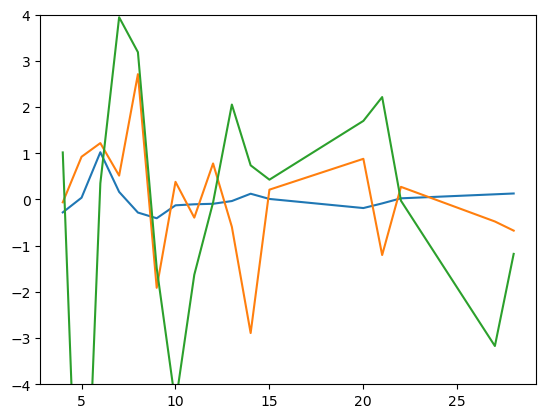

In [149]:
for zern_blend in zern_out.outputZernikesRaw:
    plt.plot(noll_indices, zern_blend)
plt.ylim(-4, 4)

In [ ]:
for idx in blended_idx:
    plt.plot(noll_indices, zern_out.outputZernikesRaw[idx])
plt.plot(noll_indices, zern_out.outputZernikesAvg[0], '--k')
plt.ylim(-4, 4)

In [87]:
zern_results = butler.get('zernikeEstimateRaw', dataId=dataId, collections=collection_name)

In [88]:
zern_results[blended_idx]

IndexError: index 19 is out of bounds for axis 0 with size 3

In [38]:
post_isr = butler.get('postISRCCD', dataId=dataId, collections=collection_name)

In [39]:
binned_image = bin2d(post_isr.image.array, 4)
v_min, v_max = ZScaleInterval().get_limits(binned_image)

In [55]:
p = figure(width=1000, height=1000, title=f"Visit: {dataId['visit']}, Detector: {dataId['detector']}", x_axis_label='X Pixels (binned 4x)', y_axis_label='Y Pixels (binned 4x)')
p.x_range.range_padding = p.y_range.range_padding = 0
color_mapper = LinearColorMapper(palette=Viridis256, low=v_min, high=v_max)
x_max, y_max = np.shape(binned_image)
p.image(image=[binned_image], x=0, y=0, dw=y_max, dh=x_max, level="image", color_mapper=color_mapper)
p.scatter(dt['centroid_x'][blended_idx]/4, dt['centroid_y'][blended_idx]/4, color='red', size=10, legend_label='Blended Donuts')

# Set font size for axis labels
p.xaxis.axis_label_text_font_size = "12pt"
p.yaxis.axis_label_text_font_size = "12pt"

# Set font size for tick labels
p.xaxis.major_label_text_font_size = "12pt"
p.yaxis.major_label_text_font_size = "12pt"

# Customize the title font size
p.title.text_font_size = "14pt"

# Customize legend
p.legend.location = "top_right"
p.legend.click_policy = "hide" 
p.legend.label_text_font_size = "12pt"

show(p)